Ref link: https://towardsdatascience.com/image-noise-reduction-in-10-minutes-with-convolutional-autoencoders-d16219d2956a

In [61]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2DTranspose, Conv2D, Input
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt
import numpy as np

In [32]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

In [33]:
print('Max value:', X_train[0].max())
print('Min value:', X_train[0].min())

Max value: 255
Min value: 0


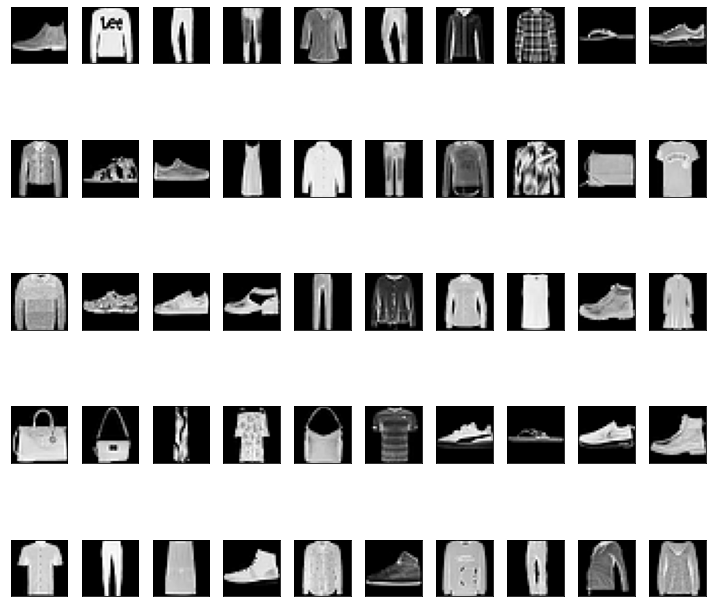

In [34]:
fig, axs = plt.subplots(5, 10, figsize=(10,10))
plt.gray()

for i in range(50):
    axs.flatten()[i].imshow(X_test[i])
    axs.flatten()[i].xaxis.set_visible(False)
    axs.flatten()[i].yaxis.set_visible(False)

plt.tight_layout()

In [35]:
# For computational efficiency, applying Min-Max normalization
# This will limit the value range btw 0 and 1
pre_X_train = X_train.astype('float32') / 255
pre_X_test = X_test.astype('float32') / 255

In [36]:
# Need to add color channel info into train and test sets
# Current: (#obs, 28, 28) but to (#obs, 28, 28, 1)
pre_X_train = pre_X_train[..., tf.newaxis]
pre_X_test = pre_X_test[..., tf.newaxis]

In [39]:
print('Train shape:', pre_X_train.shape)
print('Test shape:', pre_X_test.shape)

Train shape: (60000, 28, 28, 1)
Test shape: (10000, 28, 28, 1)


In [40]:
# Adding noise to the images
noise_factor = 0.4

X_train_noisy = pre_X_train + noise_factor * tf.random.normal(shape=pre_X_train.shape)
X_test_noisy = pre_X_test + noise_factor * tf.random.normal(shape=pre_X_test.shape)

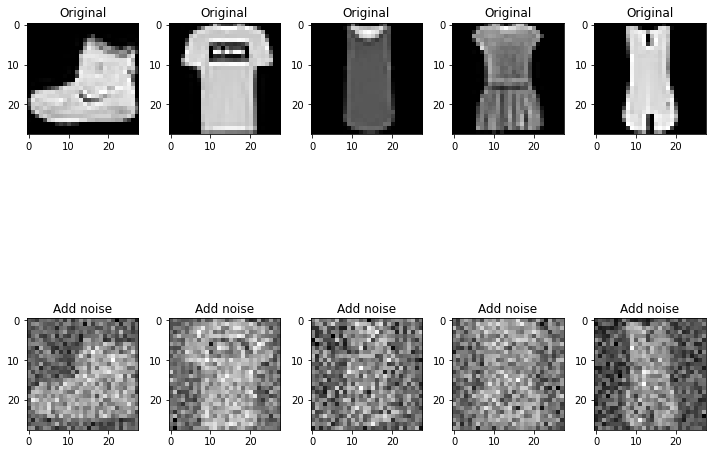

In [60]:
fig, axs = plt.subplots(2, 5, figsize=(10, 10))

for i in range(5):
    axs[0, i].imshow(X_train[i])
    axs[0, i].set_title('Original')
    
    axs[1, i].imshow(tf.squeeze(X_train_noisy[i]))
    axs[1, i].set_title('Add noise')

plt.tight_layout()

## Building a model

In [62]:
class NoiseReducer(tf.keras.Model):
    def __init__(self):
        super(NoiseReducer, self).__init__()
    
        self.encoder = tf.keras.Sequential([
                                            Input(shape=(28, 28, 1)),
                                            Conv2D(16, (3,3), activation='relu', padding='same', strides=2),
                                            Conv2D(8, (3,3), activation='relu', padding='same', strides=2)
                                            ])
        self.decoder = tf.keras.Sequential([
                                            Conv2DTranspose(8, kernel_size=3, strides=2, activation='relu', padding='same'),
                                            Conv2DTranspose(16, kernel_size=3, strides=2, activation='relu', padding='same'),
                                            Conv2D(1, kernel_size=(3,3), activation='sigmoid', padding='same')
                                            ])                                        

    def call(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        
        return decoded

In [65]:
autoencoder = NoiseReducer()

autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.fit(
    X_train_noisy, 
    pre_X_train, 
    epochs=10, 
    shuffle=True,
    validation_data=(X_test_noisy, pre_X_test))

Epoch 1/10
1875/1875 [==============================] - 70s 37ms/step - loss: 0.0237 - val_loss: 0.0160
Epoch 2/10
1875/1875 [==============================] - 68s 37ms/step - loss: 0.0154 - val_loss: 0.0150
Epoch 3/10
1875/1875 [==============================] - 68s 37ms/step - loss: 0.0147 - val_loss: 0.0147
Epoch 4/10
1875/1875 [==============================] - 69s 37ms/step - loss: 0.0144 - val_loss: 0.0143
Epoch 5/10
1875/1875 [==============================] - 69s 37ms/step - loss: 0.0141 - val_loss: 0.0142
Epoch 6/10
1875/1875 [==============================] - 68s 36ms/step - loss: 0.0139 - val_loss: 0.0139
Epoch 7/10
1875/1875 [==============================] - 68s 36ms/step - loss: 0.0138 - val_loss: 0.0138
Epoch 8/10
1875/1875 [==============================] - 68s 36ms/step - loss: 0.0137 - val_loss: 0.0137
Epoch 9/10
1875/1875 [==============================] - 69s 37ms/step - loss: 0.0136 - val_loss: 0.0137
Epoch 10/10
1875/1875 [==============================] - 69s 37m

In [83]:
encoded_img = autoencoder.encoder(X_test_noisy).numpy()
decoded_img = autoencoder.decoder(encoded_img)

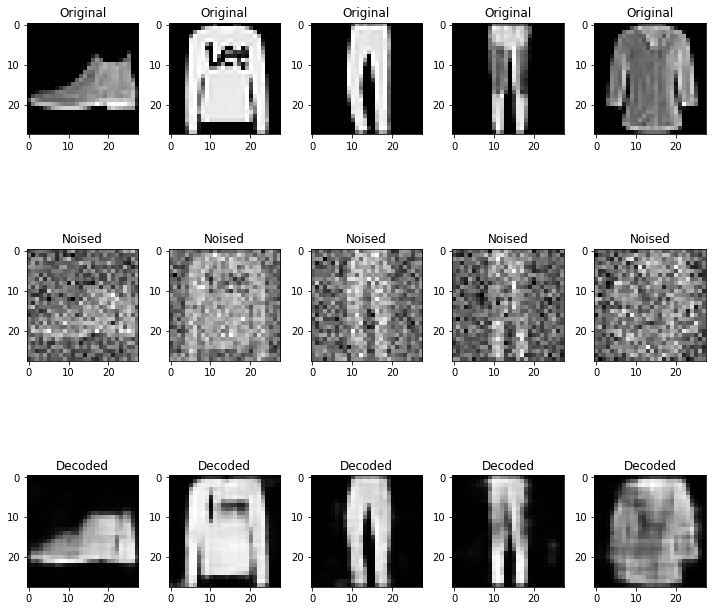

In [91]:
fig, axs = plt.subplots(3, 5, figsize=(10, 10))

for i in range(5):
    axs[0, i].imshow(X_test[i])
    axs[0, i].set_title('Original')

    axs[1, i].imshow(tf.squeeze(X_test_noisy[i]))
    axs[1, i].set_title('Noised')

    axs[2, i].imshow(tf.squeeze(decoded_img[i]))
    axs[2, i].set_title('Decoded')

plt.tight_layout()
